# Outlier

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"Data\jobselection.csv")
df

,score,exam_marks,seleted
0,7.19,26,1
1,7.46,38,1
2,7.54,40,1
3,6.42,8,1
4,7.23,17,0
...,...,...,...
995,8.87,44,1
996,9.12,65,1
997,4.89,34,0
998,8.62,46,1


# Detecting the outliers (Boxplot)

<Axes: >

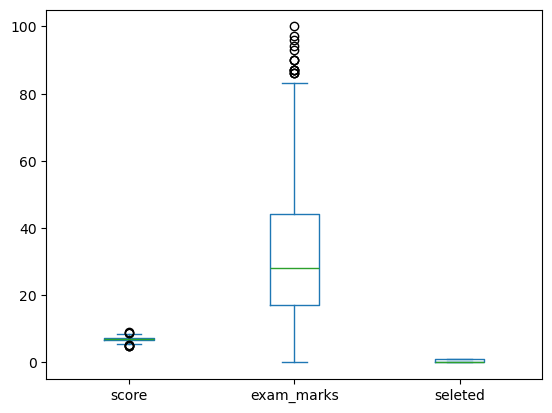

In [3]:
df.plot(kind = "box")

<Axes: >

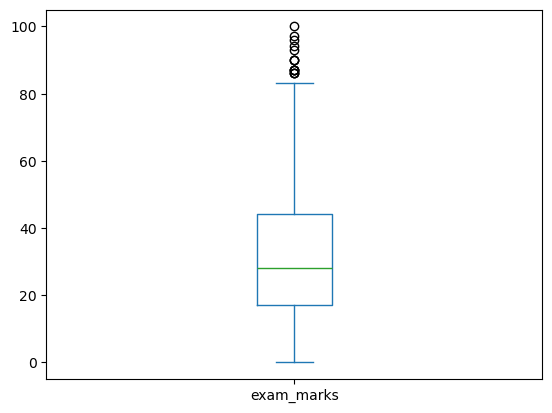

In [20]:
df["exam_marks" ].plot(kind = "box")

In [7]:
df["exam_marks"].min()

0

In [8]:
df["exam_marks"].max()

100

In [9]:
Q1 = df["exam_marks"].quantile(0.25)
Q1

np.float64(17.0)

In [11]:
Q3 = df["exam_marks"].quantile(0.75)
Q3

np.float64(44.0)

In [14]:
#calculate IQR
IQR = Q3 - Q1
IQR

np.float64(27.0)

In [22]:
lower_outlier = Q1 -(1.5*IQR)
upper_outlier = Q3 +(1.5*IQR)

In [23]:
print(lower_outlier,upper_outlier)


-23.5 84.5


In [53]:
df_trim=df[(df["exam_marks"] >= lower_outlier) & (df["exam_marks"] <= upper_outlier)]
df_trim

,score,exam_marks,seleted,Exam_marks
0,7.19,26,1,"Axes(0.125,0.11;0.775x0.77)"
1,7.46,38,1,"Axes(0.125,0.11;0.775x0.77)"
2,7.54,40,1,"Axes(0.125,0.11;0.775x0.77)"
3,6.42,8,1,"Axes(0.125,0.11;0.775x0.77)"
4,7.23,17,0,"Axes(0.125,0.11;0.775x0.77)"
...,...,...,...,...
995,8.87,44,1,"Axes(0.125,0.11;0.775x0.77)"
996,9.12,65,1,"Axes(0.125,0.11;0.775x0.77)"
997,4.89,34,0,"Axes(0.125,0.11;0.775x0.77)"
998,8.62,46,1,"Axes(0.125,0.11;0.775x0.77)"


In [44]:
df[(df["exam_marks"] >= lower_outlier) | (df["exam_marks"] <= upper_outlier)]

,score,exam_marks,seleted,Exam_marks
0,7.19,26,1,"Axes(0.125,0.11;0.775x0.77)"
1,7.46,38,1,"Axes(0.125,0.11;0.775x0.77)"
2,7.54,40,1,"Axes(0.125,0.11;0.775x0.77)"
3,6.42,8,1,"Axes(0.125,0.11;0.775x0.77)"
4,7.23,17,0,"Axes(0.125,0.11;0.775x0.77)"
...,...,...,...,...
995,8.87,44,1,"Axes(0.125,0.11;0.775x0.77)"
996,9.12,65,1,"Axes(0.125,0.11;0.775x0.77)"
997,4.89,34,0,"Axes(0.125,0.11;0.775x0.77)"
998,8.62,46,1,"Axes(0.125,0.11;0.775x0.77)"


In [38]:
df_trim.describe()

,score,exam_marks,seleted
count,985.000000,985.000000,985.00000
mean,6.961594,31.339086,0.48934
std,0.614734,17.857633,0.50014
min,4.890000,0.000000,0.00000
25%,6.550000,17.000000,0.00000
50%,6.960000,28.000000,0.00000
75%,7.370000,43.000000,1.00000
max,9.120000,83.000000,1.00000


# Capping

In [51]:
df["exam_marks"] = df["exam_marks"]. apply(lambda x :lower_outlier if x < lower_outlier else x > upper_outlier if x > upper_outlier else x)
df

,score,exam_marks,seleted,Exam_marks
0,7.19,26,1,"Axes(0.125,0.11;0.775x0.77)"
1,7.46,38,1,"Axes(0.125,0.11;0.775x0.77)"
2,7.54,40,1,"Axes(0.125,0.11;0.775x0.77)"
3,6.42,8,1,"Axes(0.125,0.11;0.775x0.77)"
4,7.23,17,0,"Axes(0.125,0.11;0.775x0.77)"
...,...,...,...,...
995,8.87,44,1,"Axes(0.125,0.11;0.775x0.77)"
996,9.12,65,1,"Axes(0.125,0.11;0.775x0.77)"
997,4.89,34,0,"Axes(0.125,0.11;0.775x0.77)"
998,8.62,46,1,"Axes(0.125,0.11;0.775x0.77)"
